# Phase 3: Time Series Decomposition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
sns.set_palette("viridis")

## 1. Load Aggregated Dataset

In [2]:
processed_dir = Path("../data/processed")
base_ts_path = processed_dir / "base_hourly_demand.parquet"

# Load and ensure it is a time series
base_ts = pd.read_parquet(base_ts_path)

# Ensure index is a sorted datetime index
if 'timestamp' in base_ts.columns:
    base_ts.set_index('timestamp', inplace=True)

base_ts.sort_index(inplace=True)
print(f"Loaded Time Series Data from {base_ts.index.min()} to {base_ts.index.max()}")
base_ts.head()

Loaded Time Series Data from 2025-01-01 00:00:00 to 2026-03-01 00:00:00


,total_demand
timestamp,
2025-01-01 00:00:00,6610
2025-01-01 01:00:00,7481
2025-01-01 02:00:00,6126
2025-01-01 03:00:00,3840
2025-01-01 04:00:00,2369


## 2. Time Series Decomposition

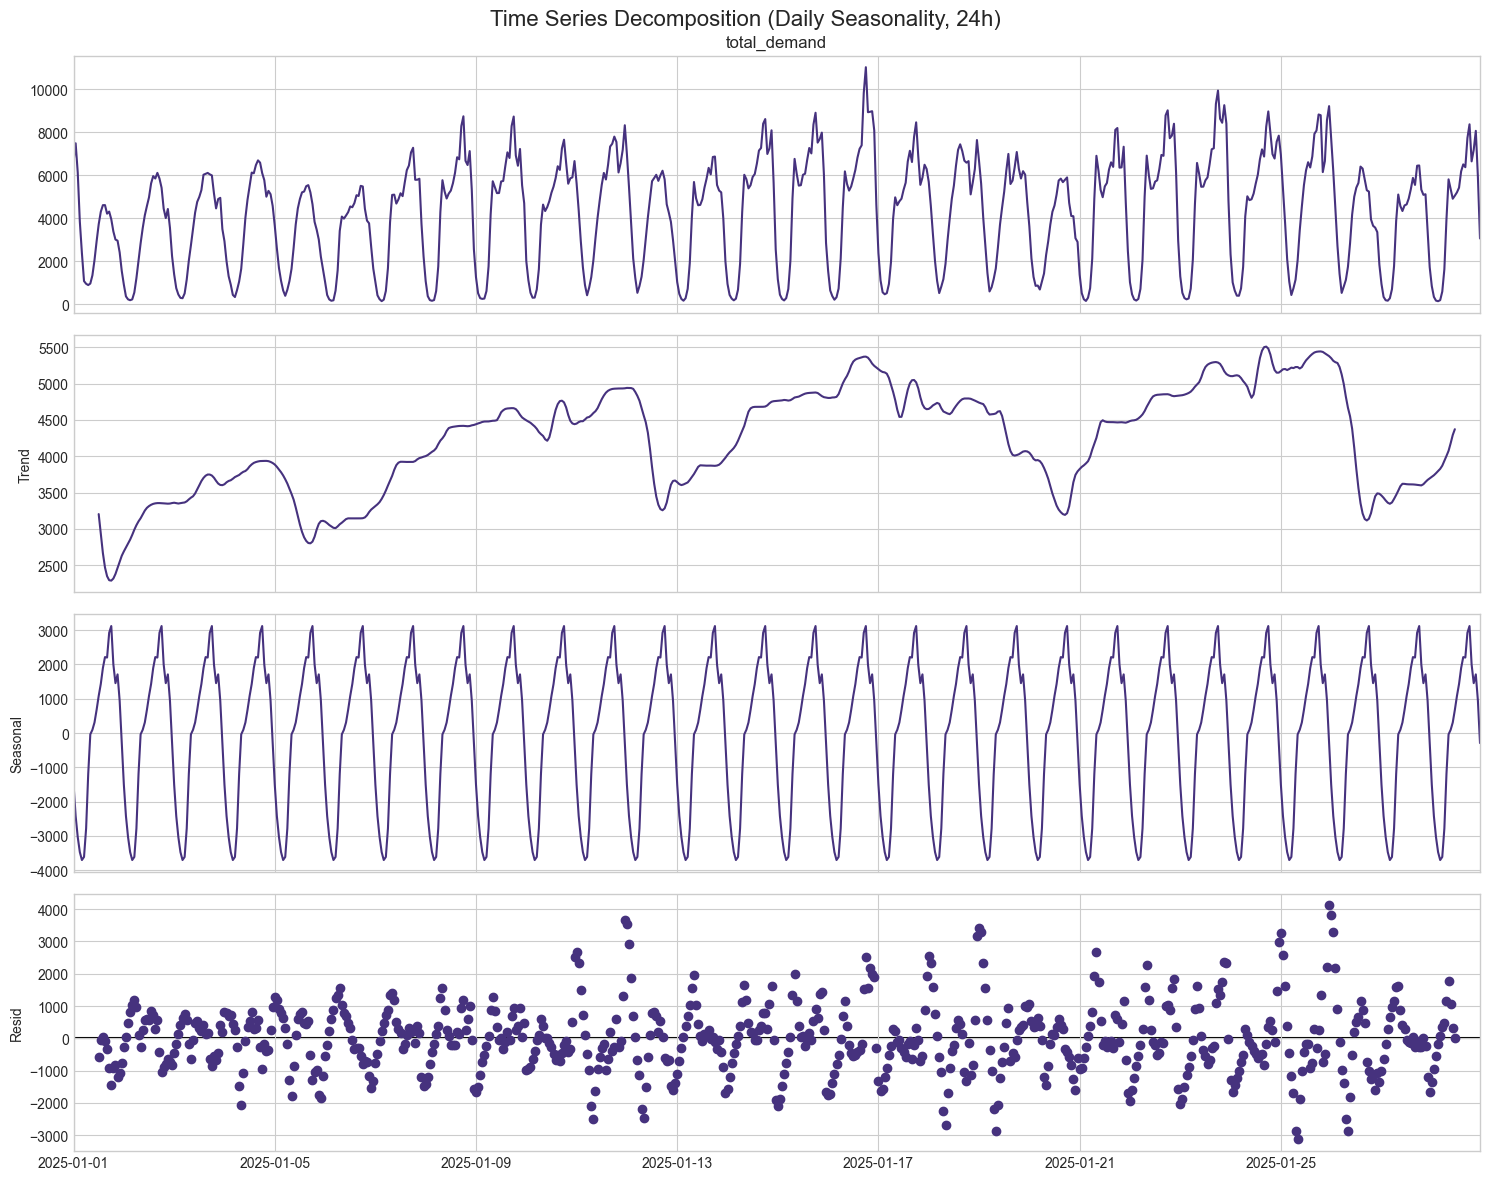

In [3]:
# We will select a subset for visualization, since rendering 2+ years of hourly data is heavily dense.
# A 4-week slice provides a very clear 24-hr and 168-hr (weekly) visual pattern.
subset_ts = base_ts['total_demand'].iloc[:24*28]

# Decompose with a period of 24 hours (Daily Seasonality)
decomposition_daily = seasonal_decompose(subset_ts, model='additive', period=24)

# Decompose with a period of 168 hours (Weekly Seasonality)
decomposition_weekly = seasonal_decompose(subset_ts, model='additive', period=168)

fig = decomposition_daily.plot()
fig.set_size_inches(15, 12)
fig.suptitle('Time Series Decomposition (Daily Seasonality, 24h)', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Analyze Seasonal Patterns

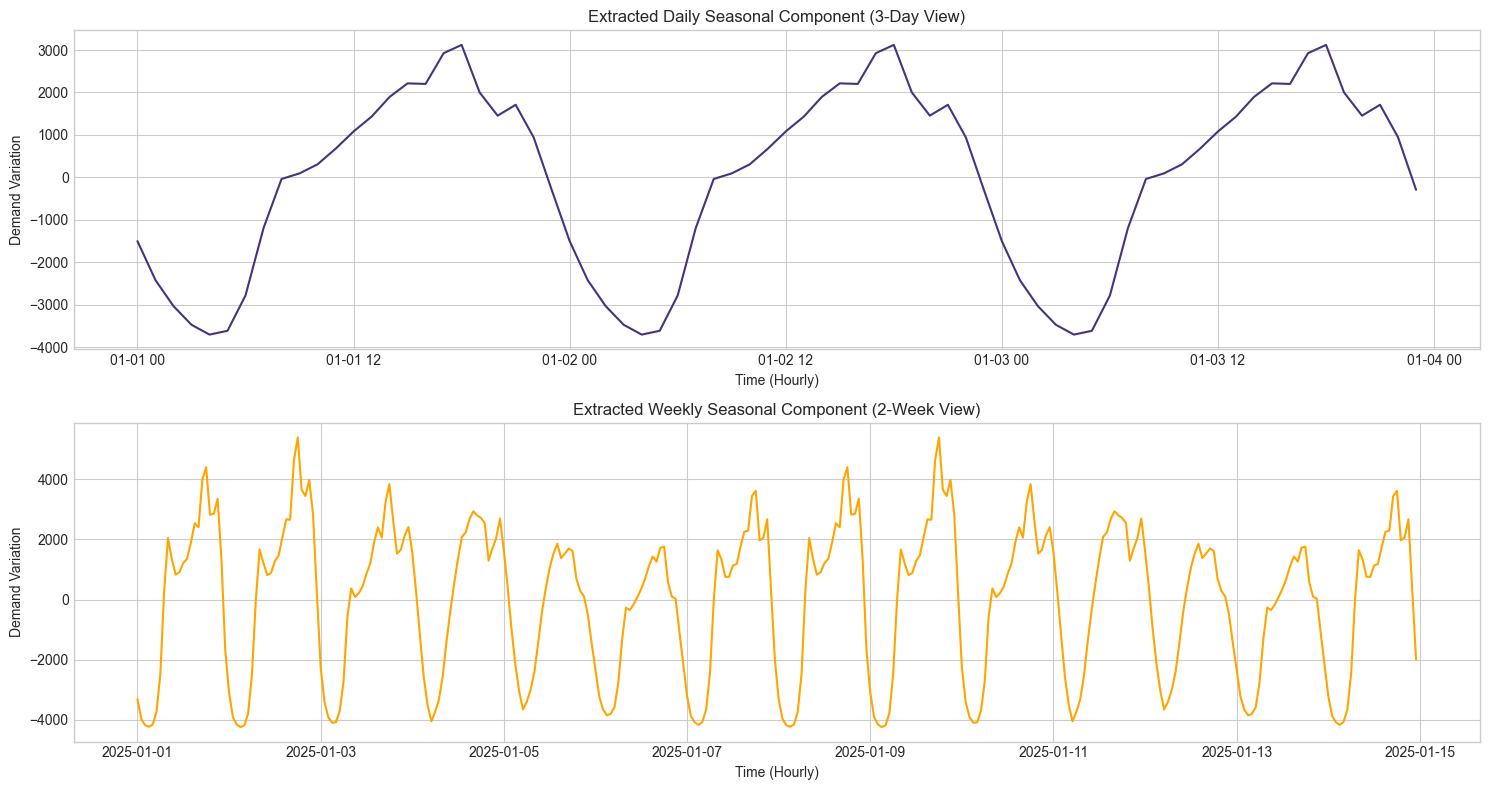

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Daily Pattern (First 3 days = 72 hours)
axes[0].plot(decomposition_daily.seasonal.iloc[:72])
axes[0].set_title('Extracted Daily Seasonal Component (3-Day View)')
axes[0].set_ylabel('Demand Variation')
axes[0].set_xlabel('Time (Hourly)')

# Weekly Pattern (First 2 weeks = 336 hours)
axes[1].plot(decomposition_weekly.seasonal.iloc[:336], color='orange')
axes[1].set_title('Extracted Weekly Seasonal Component (2-Week View)')
axes[1].set_ylabel('Demand Variation')
axes[1].set_xlabel('Time (Hourly)')

plt.tight_layout()
plt.show()